In [68]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [69]:
data = np.loadtxt('dataset.dat')

In [70]:
label = data[:,2]
feature = data[:,[0, 1]]

In [71]:
X_train, X_test, y_train, y_test = train_test_split(feature, label, test_size=0.3)

In [72]:
nombre_de_classe = np.unique(label)
nb_ex_train = len(y_train)
nb_ex_test = len(y_test)
ex_dimension = np.shape(feature)

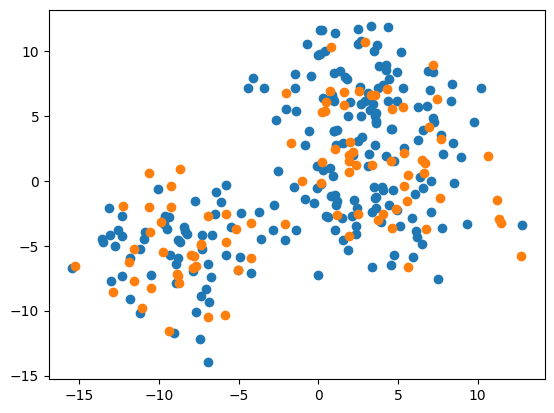

In [73]:
plt.scatter(X_train[:,0], X_train[:,1])

plt.scatter(X_test[:,0], X_test[:,1])

In [74]:
print(nombre_de_classe)
print(nb_ex_test)
print(nb_ex_train)
print(ex_dimension)

[0. 1. 2.]
90
210
(300, 2)


In [75]:
one_NN = KNeighborsClassifier(n_neighbors=1, algorithm='brute')

one_NN.fit(X_train, y_train)

KNeighborsClassifier(algorithm='brute', n_neighbors=1)

In [76]:
print(one_NN.score(X_train, y_train))
print(one_NN.score(X_test, y_test))

1.0
0.8333333333333334


In [77]:
pred = one_NN.predict(X_test)

In [78]:
cf = confusion_matrix(y_test, pred)
print(cf)

[[35  0  2]
 [ 0 18  4]
 [ 0  9 22]]


In [79]:
couleur = []

for i in y_train:
    couleur.append(int(i))


/tmp/ipykernel_7356/2025202603.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_train[:, 0], X_train[:, 1], cmap=plt.cm.Paired, color=colors[couleur])


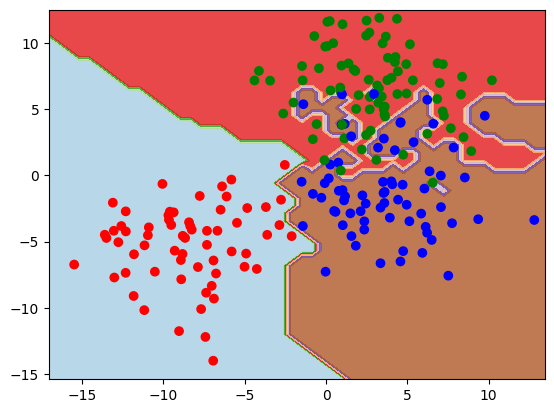

In [80]:
x_min, x_max = feature[:, 0].min()*1.1, feature[:, 0].max()*1.1
y_min, y_max = feature[:, 1].min()*1.1, feature[:, 1].max()*1.1
x_h = (x_max - x_min)/50
y_h = (y_max - y_min)/50
xx, yy = np.meshgrid(np.arange(x_min, x_max, x_h),
np.arange(y_min, y_max, y_h))
Y = one_NN.predict(np.c_[xx.ravel(), yy.ravel()])
Y = Y.reshape(xx.shape)
#afficher les frontières/données d'apprentissage
plt.contourf(xx, yy, Y, cmap=plt.cm.Paired, alpha=0.8)
colors = np.array([x for x in "rgbcmyk"])
plt.scatter(X_train[:, 0], X_train[:, 1], cmap=plt.cm.Paired, color=colors[couleur])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

In [81]:
c_test = []

for i in y_test:
    c_test.append(int(i))

/tmp/ipykernel_7356/3786757748.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_test[:, 0], X_test[:, 1], cmap=plt.cm.Paired, color=colors[c_test].tolist())


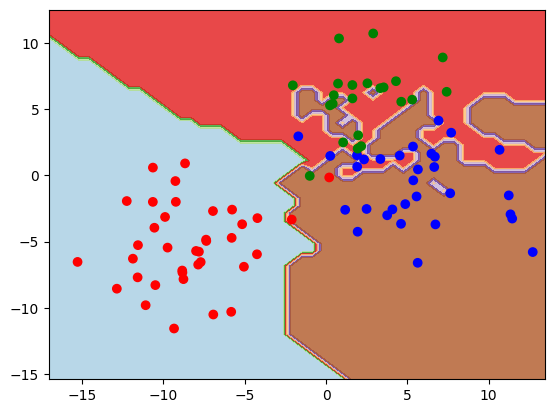

In [82]:
x_min, x_max = feature[:, 0].min()*1.1, feature[:, 0].max()*1.1
y_min, y_max = feature[:, 1].min()*1.1, feature[:, 1].max()*1.1
x_h = (x_max - x_min)/50
y_h = (y_max - y_min)/50
xx, yy = np.meshgrid(np.arange(x_min, x_max, x_h),
np.arange(y_min, y_max, y_h))
Y = one_NN.predict(np.c_[xx.ravel(), yy.ravel()])
Y = Y.reshape(xx.shape)
#afficher les frontières/données d'apprentissage
plt.contourf(xx, yy, Y, cmap=plt.cm.Paired, alpha=0.8)
colors = np.array([x for x in "rgbcmyk"])
plt.scatter(X_test[:, 0], X_test[:, 1], cmap=plt.cm.Paired, color=colors[c_test].tolist())
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

In [83]:
train_score = []

for i in range(1, 100, 1):
    X_train1, _, y_train1, _ = train_test_split(X_train, y_train, train_size=i/100)
    new_NN = KNeighborsClassifier(n_neighbors=1, algorithm='brute').fit(X_train1, y_train1)

    train_score.append(new_NN.score(X_test, y_test))

print(train_score)

[0.24444444444444444, 0.7333333333333333, 0.7444444444444445, 0.9, 0.7111111111111111, 0.7666666666666667, 0.8888888888888888, 0.9222222222222223, 0.9, 0.8, 0.9222222222222223, 0.9222222222222223, 0.9, 0.8444444444444444, 0.8777777777777778, 0.8666666666666667, 0.9222222222222223, 0.8555555555555555, 0.8666666666666667, 0.8111111111111111, 0.8111111111111111, 0.8222222222222222, 0.8222222222222222, 0.8888888888888888, 0.8666666666666667, 0.9111111111111111, 0.9111111111111111, 0.8555555555555555, 0.7555555555555555, 0.9111111111111111, 0.8222222222222222, 0.8444444444444444, 0.8777777777777778, 0.8, 0.8333333333333334, 0.8, 0.8222222222222222, 0.8444444444444444, 0.8777777777777778, 0.8555555555555555, 0.7777777777777778, 0.8111111111111111, 0.8333333333333334, 0.8666666666666667, 0.8444444444444444, 0.8555555555555555, 0.8888888888888888, 0.8222222222222222, 0.8333333333333334, 0.8444444444444444, 0.8111111111111111, 0.7666666666666667, 0.8777777777777778, 0.7666666666666667, 0.877777

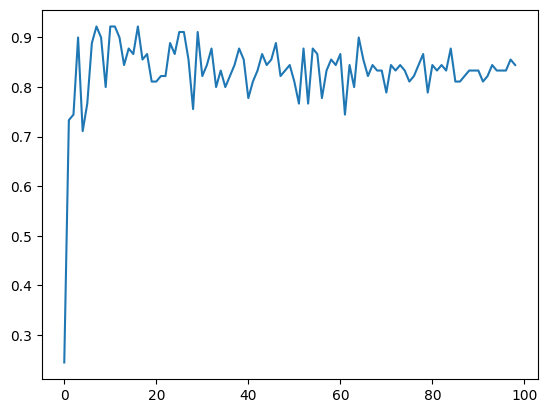

In [84]:
plt.plot(train_score)

In [90]:
test_score = []

for i in range(1, 90, 1):
    X_test1, _, y_test1, _ = train_test_split(X_test, y_test, train_size=i/90)
    new_NN = KNeighborsClassifier(n_neighbors=1, algorithm='brute').fit(X_train, y_train)

    test_score.append(new_NN.score(X_test1, y_test1))

print(test_score)

[1.0, 0.5, 0.6666666666666666, 0.75, 0.8, 0.8333333333333334, 0.8571428571428571, 0.625, 0.8888888888888888, 0.7, 0.7272727272727273, 0.8333333333333334, 0.75, 0.7142857142857143, 1.0, 0.8125, 0.8823529411764706, 0.8333333333333334, 0.8947368421052632, 0.75, 0.9047619047619048, 0.9090909090909091, 0.782608695652174, 0.875, 0.84, 0.88, 0.7037037037037037, 0.8571428571428571, 0.896551724137931, 0.8, 0.8387096774193549, 0.84375, 0.8181818181818182, 0.8823529411764706, 0.8571428571428571, 0.7777777777777778, 0.8378378378378378, 0.868421052631579, 0.8461538461538461, 0.875, 0.7804878048780488, 0.8809523809523809, 0.7674418604651163, 0.8636363636363636, 0.8, 0.782608695652174, 0.851063829787234, 0.8333333333333334, 0.75, 0.86, 0.7843137254901961, 0.8431372549019608, 0.8490566037735849, 0.8148148148148148, 0.8, 0.8571428571428571, 0.8596491228070176, 0.8103448275862069, 0.8135593220338984, 0.8833333333333333, 0.819672131147541, 0.8387096774193549, 0.8064516129032258, 0.8125, 0.815384615384615

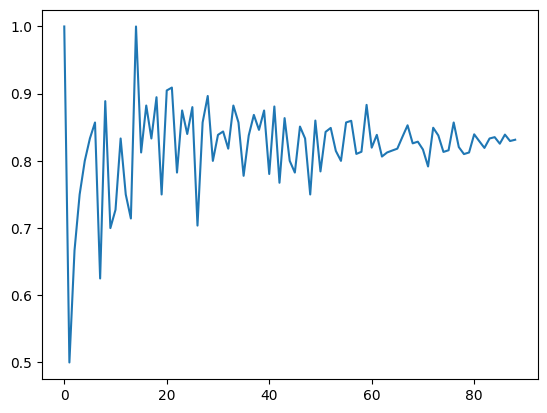

In [91]:
plt.plot(test_score)

4.

[0.8222222222222222, 0.7777777777777778, 0.8111111111111111, 0.8111111111111111, 0.8111111111111111, 0.8333333333333334, 0.8444444444444444, 0.8333333333333334, 0.8222222222222222, 0.8222222222222222, 0.8222222222222222, 0.8222222222222222, 0.8, 0.8222222222222222, 0.8222222222222222, 0.8222222222222222, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8444444444444444, 0.8333333333333334, 0.8333333333333334, 0.8444444444444444, 0.8666666666666668, 0.8555555555555555, 0.8555555555555555, 0.8555555555555555, 0.8666666666666668, 0.8666666666666668, 0.8666666666666668, 0.8666666666666668, 0.8777777777777779, 0.8777777777777779, 0.8777777777777779, 0.8777777777777779, 0.8777777777777779, 0.8777777777777779, 0.8777777777777779, 0.888888888888889, 0.8777777777777779, 0.888888888888889, 0.888888888888889, 0.888888888888889, 0.888888888888889, 0.888888888888889, 0.8777777777777779, 0.888888888888889, 0.888888888888889, 0.888888888888889, 0.888888888888889, 0.9, 0.9, 0.9, 0.9, 0.88

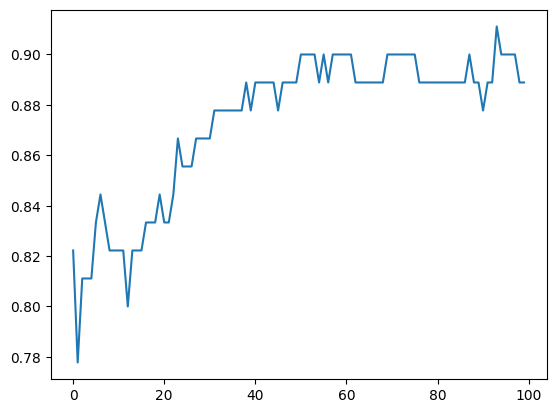

In [104]:
X_train, X_test, y_train, y_test = train_test_split(feature, label, test_size=0.3)

proba = []
proba_var = []
for i in range(1, 101, 1):
    tab = []
    v = []
    for _ in range(10):
        k_KNN = KNeighborsClassifier(n_neighbors=i, algorithm='brute')
        k_KNN.fit(X_train, y_train)

        tab.append(k_KNN.score(X_test, y_test))
        v.append(np.var())
    proba.append(np.mean(tab))

print(proba)
plt.plot(proba)